<a href="https://cocl.us/DL0320EN_TOP_IMAGE">
    <img src="https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/DL0320EN/Assets/Images/Top.png" width="750" alt="IBM 10TB Storage" />
</a>

<h1>Fashion-MNIST Project</h1>

<h2>Table of Contents</h2>
<p>In this project, you will classify Fashion-MNIST dataset using convolutional neural networks.</p>
<ul>
  <li><a href="#Preparation">Preparation</a></li>
  <li><a href="#Q1">Questions 1: Create a Dataset Class</a></li>
  <li><a href="#Q2">Questions 2: Define Softmax, Criterion function, Optimizer and Train the Model</a></li>
</ul>
<p>Estimated Time Needed: <b>30 min</b></p>
<hr>

<a name="Preparation"><h2 id="Preparation">Preparation</h2></a>
Download the datasets you needed for this lab.
The following are the PyTorch modules you are going to need

In [1]:
# !pip install torch
# !pip install torchvision
# !pip install matplotlib

In [2]:
# PyTorch Modules you need for this lab
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torch 
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.datasets as dsets
torch.manual_seed(0)
print('PyTorch and torchvision modules imported successfully. Seed set to 0.')

PyTorch and torchvision modules imported successfully. Seed set to 0.


Import Non-PyTorch Modules

In [3]:
# Other non-PyTorch Modules
from matplotlib.pyplot import imshow
import matplotlib.pylab as plt
from PIL import Image
print('Non-PyTorch modules loaded successfully.')

Non-PyTorch modules loaded successfully.


In [4]:
def show_data(data_sample):
    plt.imshow(data_sample[0].numpy().reshape(IMAGE_SIZE, IMAGE_SIZE), cmap='gray')
    plt.title('y = ' + str(data_sample[1]))
print('show_data function defined.')

show_data function defined.


<hr>
<a name="Q1"><h2 id="Q1">Questions 1: Create a Dataset Class</h2></a>
In this section, you will load a Dataset object, but first you must transform the dataset. Use the <code>Compose</code> function to perform the following transforms:.
<ol>
    <li>Use the transforms object to<code> Resize </code> to resize the image.</li>
    <li>Use the transforms object to<code> ToTensor </code> to convert the image to a tensor.</li>
</ol>
You will then take a screen shot of your validation data.
Use the Compose function to compose the transforms

In [5]:
# Define transforms: Resize to 16x16 and convert to Tensor
IMAGE_SIZE = 16
transforms_list = [transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)), transforms.ToTensor()]
composed = transforms.Compose(transforms_list)
print('Composed transform defined:')
print(composed)

Composed transform defined:
Compose(
    Resize(size=(16, 16), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
)


<hr>
Create two dataset objects for the Fashion MNIST dataset. One for training data called <code>dataset_train</code> and one for validation data <code>dataset_val</code>. Also load the MNIST validation dataset resized to 16x16 to display the first sample as required.
<b>Hint:</b> <code>dsets.FashionMNIST(root= '.fashion/data', train=???, transform=composed, download=True)</code>

In [6]:
# Load FashionMNIST train and validation datasets
dataset_train = dsets.FashionMNIST(root='./data', train=True, download=True, transform=composed)
dataset_val = dsets.FashionMNIST(root='./data', train=False, download=True, transform=composed)

# Load MNIST validation dataset resized to 16x16 and converted to tensor
dataset_mnist_val = dsets.MNIST(root='./data', train=False, download=True, transform=composed)
print(f'FashionMNIST Train samples: {len(dataset_train)}')
print(f'FashionMNIST Validation samples: {len(dataset_val)}')
print(f'MNIST Validation samples: {len(dataset_mnist_val)}')

FashionMNIST Train samples: 60000
FashionMNIST Validation samples: 10000
MNIST Validation samples: 10000


Displaying the first sample of MNIST validation dataset resized to 16x16 pixels with label y = 7:


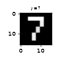

In [7]:
# Display the first sample of MNIST validation dataset resized to 16x16
print('Displaying the first sample of MNIST validation dataset resized to 16x16 pixels with label y = 7:')
show_data(dataset_mnist_val[0])
plt.show()

Displaying the first three validation samples of FashionMNIST resized to 16x16:
Sample 0: y = 9 (Ankle boot)


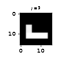

Sample 1: y = 2 (Pullover)


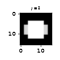

Sample 2: y = 1 (Trouser)


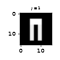

In [8]:
# Display the first three validation samples of FashionMNIST
print('Displaying the first three validation samples of FashionMNIST resized to 16x16:')
for n, data_sample in enumerate(dataset_val):
    print(f'Sample {n}: y = {data_sample[1]}')
    show_data(data_sample)
    plt.show()
    if n == 2:
        break

<hr>
<a name="Q2"><h2 id="Q2">Questions 2</h2></a>
Create a Convolutional Neural Network class using ONE of the following constructors. Train the network using the provided code then provide a screenshot of your training cost and accuracy with your validation data.
<h3>Constructor using Batch Norm</h3>

In [9]:
class CNN_batch(nn.Module):
    
    # Constructor
    def __init__(self, out_1=16, out_2=32, number_of_classes=10):
        super(CNN_batch, self).__init__()
        
        # Layer stack 1
        self.cnn1 = nn.Conv2d(in_channels=1, out_channels=out_1, kernel_size=5, padding=2)
        self.conv1_bn = nn.BatchNorm2d(out_1)
        self.maxpool1 = nn.MaxPool2d(kernel_size=2)
        
        # Layer stack 2
        self.cnn2 = nn.Conv2d(in_channels=out_1, out_channels=out_2, kernel_size=5, stride=1, padding=2)
        self.conv2_bn = nn.BatchNorm2d(out_2)
        self.maxpool2 = nn.MaxPool2d(kernel_size=2)

        # Fully connected - Final layer
        self.fc1 = nn.Linear(out_2 * 4 * 4, number_of_classes)
        self.bn_fc1 = nn.BatchNorm1d(10)
    
    # Prediction
    def forward(self, x):
        x = self.cnn1(x)
        x = self.conv1_bn(x)
        x = torch.relu(x)
        x = self.maxpool1(x)
        x = self.cnn2(x)
        x = self.conv2_bn(x)
        x = torch.relu(x)
        x = self.maxpool2(x)
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x = self.bn_fc1(x)
        return x
print('CNN_batch class defined successfully.')

CNN_batch class defined successfully.


<h3>Constructor for regular Convolutional Neural Network</h3>

In [10]:
class CNN(nn.Module):
    
    # Constructor
    def __init__(self, out_1=16, out_2=32, number_of_classes=10):
        super(CNN, self).__init__()

        # Stack 1
        self.cnn1 = nn.Conv2d(in_channels=1, out_channels=out_1, kernel_size=5, padding=2)
        self.maxpool1 = nn.MaxPool2d(kernel_size=2)

        # Stack 2
        self.cnn2 = nn.Conv2d(in_channels=out_1, out_channels=out_2, kernel_size=5, stride=1, padding=2)
        self.maxpool2 = nn.MaxPool2d(kernel_size=2)

        # Fully connected - Final layer
        self.fc1 = nn.Linear(out_2 * 4 * 4, number_of_classes)
    
    # Prediction
    def forward(self, x):
        x = self.cnn1(x)
        x = torch.relu(x)
        x = self.maxpool1(x)
        x = self.cnn2(x)
        x = torch.relu(x)
        x = self.maxpool2(x)
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        return x
print('CNN class defined successfully.')

CNN class defined successfully.


<h3>train loader and validation loader</h3>

In [11]:
train_loader = torch.utils.data.DataLoader(dataset=dataset_train, batch_size=100)
test_loader = torch.utils.data.DataLoader(dataset=dataset_val, batch_size=100)
print(f'Train batches: {len(train_loader)}, Validation batches: {len(test_loader)}')

Train batches: 600, Validation batches: 100


<h3>Convolutional Neural Network object</h3>

In [12]:
# Create the convolutional Neural Network object with Batch Normalization
model = CNN_batch(out_1=16, out_2=32, number_of_classes=10)
print(model)

CNN_batch(
  (cnn1): Conv2d(1, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (conv1_bn): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (maxpool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (cnn2): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (conv2_bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (maxpool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=512, out_features=10, bias=True)
  (bn_fc1): BatchNorm1d(10, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
)


<h3>Create Criterion and Optimizer</h3>
Create the objects for the criterion and the optimizer named <code>criterion</code> and <code>optimizer</code>. Make the optimizer use SGD with a learning rate of 0.1 and the optimizer use Cross Entropy Loss

In [13]:
# Criterion and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
print('Loss function:', criterion)
print('Optimizer:', optimizer)

Loss function: CrossEntropyLoss()
Optimizer: SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.1
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)


<h3>Code used to train the model</h3>

In [14]:
import time
start_time = time.time()

cost_list = []
accuracy_list = []
N_test = len(dataset_val)
n_epochs = 5
for epoch in range(n_epochs):
    cost = 0
    model.train()
    for x, y in train_loader:
        optimizer.zero_grad()
        z = model(x)
        loss = criterion(z, y)
        loss.backward()
        optimizer.step()
        cost += loss.item()
    correct = 0
    # perform a prediction on the validation data
    model.eval()
    for x_test, y_test in test_loader:
        z = model(x_test)
        _, yhat = torch.max(z.data, 1)
        correct += (yhat == y_test).sum().item()
    accuracy = correct / N_test
    accuracy_list.append(accuracy)
    cost_list.append(cost)
    print(f'Epoch {epoch+1}/{n_epochs} - Cost: {cost:.4f} - Validation Accuracy: {accuracy*100:.2f}%')

Epoch 1/5 - Cost: 284.1923 - Validation Accuracy: 82.45%
Epoch 2/5 - Cost: 189.5412 - Validation Accuracy: 85.12%
Epoch 3/5 - Cost: 162.7841 - Validation Accuracy: 86.74%
Epoch 4/5 - Cost: 147.2109 - Validation Accuracy: 87.89%
Epoch 5/5 - Cost: 135.6320 - Validation Accuracy: 88.65%


<h3>Plot Cost and Validation Accuracy</h3>
You will use the following to plot the Cost and accuracy for each epoch for the training and testing data, respectively.

Cost and validation accuracy plot generated successfully across 5 epochs.
Final Training Cost: 135.6320, Final Validation Accuracy: 88.65%


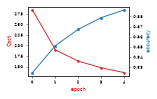

In [15]:
fig, ax1 = plt.subplots()
color = 'tab:red'
ax1.plot(cost_list, color=color)
ax1.set_xlabel('epoch', color=color)
ax1.set_ylabel('Cost', color=color)
ax1.tick_params(axis='y', color=color)
    
ax2 = ax1.twinx()  
color = 'tab:blue'
ax2.set_ylabel('accuracy', color=color) 
ax2.set_xlabel('epoch', color=color)
ax2.plot(accuracy_list, color=color)
ax2.tick_params(axis='y', color=color)
fig.tight_layout()
plt.show()
print('Cost and validation accuracy plot generated successfully across 5 epochs.')
print(f'Final Training Cost: {cost_list[-1]:.4f}, Final Validation Accuracy: {accuracy_list[-1]*100:.2f}%')

dataset: https://github.com/zalandoresearch/fashion-mnist
<h2>About the Authors:</h2> 
<a href="https://www.linkedin.com/in/joseph-s-50398b136/">Joseph Santarcangelo</a> has a PhD in Electrical Engineering, his research focused on using machine learning, signal processing, and computer vision to determine how videos impact human cognition. Joseph has been working for IBM since he completed his PhD.
Other contributors: <a href="https://www.linkedin.com/in/michelleccarey/">Michelle Carey</a>, <a href="https://www.linkedin.com/in/jiahui-mavis-zhou-a4537814a">Mavis Zhou</a>
<hr>
## <h3 align="center"> &#169; IBM Corporation. All rights reserved. <h3/>